In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import json
import shap



Total de jogos: 955
Vitórias do time 1 (team_1): 487
Vitórias do time 2 (team_2): 468
Percentual de vitórias do lado azul: 50.99%


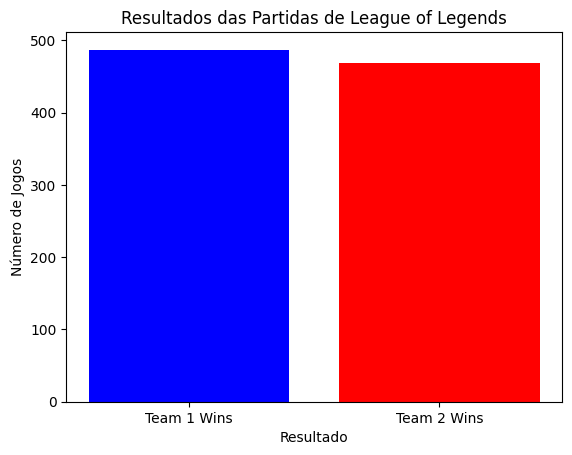

In [53]:
file_path = '../../repository/lck/LCK_matches_4.csv'

# Carregar os dados organizados
df = pd.read_csv(file_path)

# Total de jogos
total_matches = df.shape[0]

# Contagem de vitórias
team_1_wins = (df['winner'] == df['team_1']).sum()
team_2_wins = (df['winner'] == df['team_2']).sum()


# Lista de valores para os times e seus resultados
win_counts = [team_1_wins, team_2_wins]

# Cálculo da porcentagem de vitórias do time 1
team_1_win_rate = (team_1_wins / total_matches) * 100

# Exibir estatísticas
print("Total de jogos:", total_matches)
print("Vitórias do time 1 (team_1):", team_1_wins)
print("Vitórias do time 2 (team_2):", team_2_wins)
print(f"Percentual de vitórias do lado azul: {team_1_win_rate:.2f}%")

# Criar gráfico de barras
x = ['Team 1 Wins', 'Team 2 Wins']
y = win_counts

plt.bar(x, y, color=['blue', 'red'])
plt.xlabel('Resultado')
plt.ylabel('Número de Jogos')
plt.title('Resultados das Partidas de League of Legends')
plt.show()


In [54]:
matches_df = pd.read_csv(file_path)
# Ordenar os dados pelas datas dos jogos para manter a ordem cronológica
# Pois temos informação temporal.
matches_df = matches_df.sort_values(by='date')
print(matches_df.head())

                 match_id             team_1               team_2 league  \
21  ESPORTSTMNT01_2700815                DRX         Liiv SANDBOX    LCK   
0   ESPORTSTMNT01_2690695                DRX         Liiv SANDBOX    LCK   
1   ESPORTSTMNT01_2690705                 T1     Kwangdong Freecs    LCK   
2   ESPORTSTMNT01_2690725   Kwangdong Freecs                   T1    LCK   
22  ESPORTSTMNT01_2701248  Nongshim RedForce  Hanwha Life Esports    LCK   

                   date             winner  gamelength    firsttower_team  \
21  2022-01-12 06:20:03       Liiv SANDBOX        2195                DRX   
0   2022-01-12 09:02:13       Liiv SANDBOX        2070                DRX   
1   2022-01-12 10:07:10                 T1        2233   Kwangdong Freecs   
2   2022-01-12 11:49:28                 T1        1506                 T1   
22  2022-01-13 06:51:40  Nongshim RedForce        2153  Nongshim RedForce   

      firstblood_team   firstdragon_team  
21                DRX       Liiv SAND

In [56]:
# Verificar se há valores nulos em todo o DataFrame
print("Contagem de valores nulos em cada coluna:")
print(matches_df.isna().sum())

# Verificar se há linhas com valores nulos e exibir essas linhas
linhas_com_na = matches_df[matches_df.isna().any(axis=1)]
if not linhas_com_na.empty:
    print("\nLinhas com valores nulos:")
    print(linhas_com_na)
else:
    print("\nNenhuma linha com valores nulos encontrada.")

# Exibir as colunas específicas que têm valores ausentes
colunas_com_na = matches_df.columns[matches_df.isna().any()]
print("\nColunas com valores ausentes:", colunas_com_na.tolist())

# Remover linhas com valores nulos em qualquer coluna e atualizar o DataFrame
matches_df = matches_df.dropna()

print("\nDataFrame atualizado sem valores nulos")

Contagem de valores nulos em cada coluna:
match_id            0
team_1              0
team_2              0
league              0
date                0
winner              0
gamelength          0
firsttower_team     0
firstblood_team     0
firstdragon_team    0
dtype: int64

Nenhuma linha com valores nulos encontrada.

Colunas com valores ausentes: []

DataFrame atualizado sem valores nulos


In [57]:
# Encode team names and league
le_team = LabelEncoder()
le_league = LabelEncoder()

matches_df['game_id'] = matches_df.index
matches_df['team_1_encoded'] = le_team.fit_transform(matches_df['team_1'])
matches_df['team_2_encoded'] = le_team.fit_transform(matches_df['team_2'])
matches_df['league_encoded'] = le_league.fit_transform(matches_df['league'])
matches_df['result_encoded'] = (matches_df['winner'] == matches_df['team_1']).astype(int)
matches_df['firsttower_team_encoded'] = le_team.fit_transform(matches_df['firsttower_team'])
matches_df['firstblood_team_encoded'] = le_team.fit_transform(matches_df['firstblood_team'])
matches_df['firstdragon_team_encoded'] = le_team.fit_transform(matches_df['firstdragon_team'])



# Variáveis que serão usadas para treinar o modelo
# Features: (team names 1: team names 2 : league: tempo de jogo)
X = matches_df[['team_1_encoded', 'team_2_encoded', 'league_encoded', 'gamelength', 'firsttower_team_encoded', 'firstblood_team_encoded', 'firstdragon_team_encoded']]

# Target: vencedor (codificado como 0 ou 1 com base em se o time_1 é o vencedor)
y = matches_df['result_encoded']

display(matches_df.head())


,match_id,team_1,team_2,league,date,winner,gamelength,firsttower_team,firstblood_team,firstdragon_team,game_id,team_1_encoded,team_2_encoded,league_encoded,result_encoded,firsttower_team_encoded,firstblood_team_encoded,firstdragon_team_encoded
21,ESPORTSTMNT01_2700815,DRX,Liiv SANDBOX,LCK,2022-01-12 06:20:03,Liiv SANDBOX,2195,DRX,DRX,Liiv SANDBOX,21,1,7,0,0,1,1,7
0,ESPORTSTMNT01_2690695,DRX,Liiv SANDBOX,LCK,2022-01-12 09:02:13,Liiv SANDBOX,2070,DRX,Liiv SANDBOX,Liiv SANDBOX,0,1,7,0,0,1,7,7
1,ESPORTSTMNT01_2690705,T1,Kwangdong Freecs,LCK,2022-01-12 10:07:10,T1,2233,Kwangdong Freecs,T1,T1,1,10,6,0,1,6,10,10
2,ESPORTSTMNT01_2690725,Kwangdong Freecs,T1,LCK,2022-01-12 11:49:28,T1,1506,T1,T1,T1,2,6,10,0,0,10,10,10
22,ESPORTSTMNT01_2701248,Nongshim RedForce,Hanwha Life Esports,LCK,2022-01-13 06:51:40,Nongshim RedForce,2153,Nongshim RedForce,Nongshim RedForce,Nongshim RedForce,22,8,4,0,1,8,8,8


In [58]:
# Normalização dos dados de entrada (features)
scaler = MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)
print('Features: ', X_scaled.shape)
print(X_scaled)

Features:  (954, 7)
[[0.1 0.7 0.  ... 0.1 0.1 0.7]
 [0.1 0.7 0.  ... 0.1 0.7 0.7]
 [1.  0.6 0.  ... 0.6 1.  1. ]
 ...
 [0.3 1.  0.  ... 1.  0.3 0.3]
 [1.  0.3 0.  ... 0.3 0.3 1. ]
 [0.3 1.  0.  ... 1.  0.3 1. ]]


In [59]:
# Definir percentuais de treino, teste e previsão
# Treino      representa 80% dos dados
# Teste       representa 10% dos dados
# Previsão    representa 10% dos dados
train_ratio = 0.8
test_ratio = 0.1

# Calcular os índices para separação
total_matches = matches_df.shape[0]

train_size = int(train_ratio * total_matches)
test_size = int(test_ratio * total_matches)

# Separação manual dos dados
X_train = X_scaled[:train_size]
y_train = y[:train_size]

X_test = X_scaled[train_size:train_size + test_size]
y_test = y[train_size:train_size + test_size]

X_prediction = X_scaled[train_size + test_size:]

print(len(X_train), len(y_train))
print(len(X_test), len(y_test))


763 763
95 95


Using 763 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Acurácia do modelo de Naive Bayes: 38.95%
F1 Score: 38.95%%


  0%|          | 0/95 [00:00<?, ?it/s]

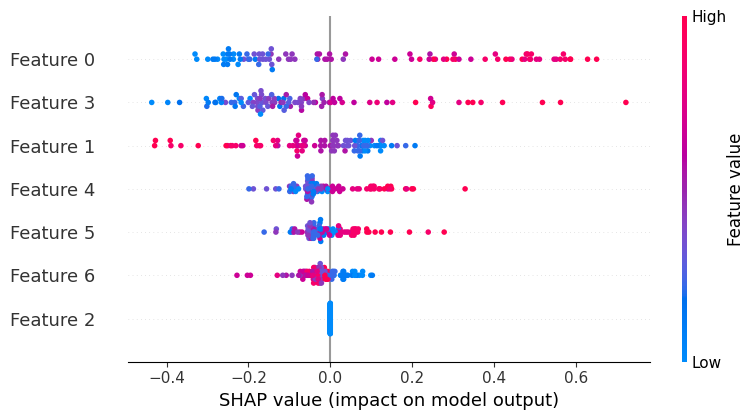

In [60]:
# Criar o modelo Naive Bayes
model = GaussianNB()

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões
y_pred = model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average = 'micro')

print(f'Acurácia do modelo de Naive Bayes: {accuracy * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')

# Valores positivos de SHAP indicam um recurso que está elevando a previsão do modelo, enquanto valores negativos sugerem que o recurso está elevando a previsão para baixo.
explainer_model = shap.KernelExplainer(model.predict, X_train)
shap_values = explainer_model.shap_values(X_test)

# Criar o gráfico de resumo dos valores SHAP
shap.summary_plot(shap_values, X_test)

Using 763 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Acurácia do modelo de Regressão Logística: 45.26%
F1 Score: 45.26%%


  0%|          | 0/95 [00:00<?, ?it/s]

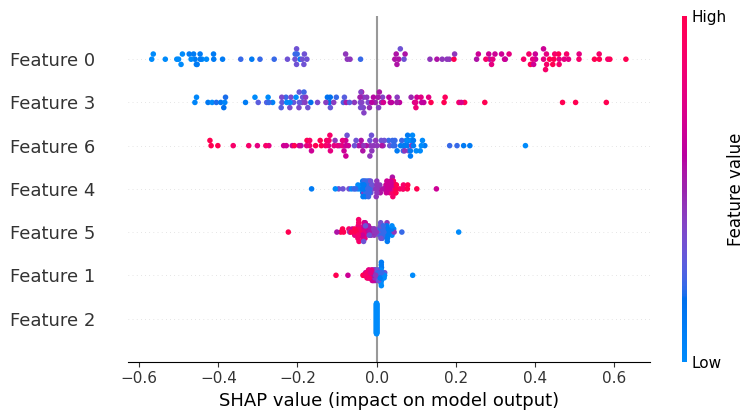

In [61]:
# Criar o modelo de Regressão Logística
logistic_model = LogisticRegression()

# Treinar o modelo
logistic_model.fit(X_train, y_train)

# Fazer previsões
y_pred_logistic = logistic_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic, average = 'micro')

print(f'Acurácia do modelo de Regressão Logística: {accuracy_logistic * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


# Valores positivos de SHAP indicam um recurso que está elevando a previsão do modelo, enquanto valores negativos sugerem que o recurso está elevando a previsão para baixo.
explainer_model = shap.KernelExplainer(logistic_model.predict, X_train)
shap_values = explainer_model.shap_values(X_test)

# Criar o gráfico de resumo dos valores SHAP
shap.summary_plot(shap_values, X_test)


Using 763 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Acurácia do modelo SVM: 69.47%
F1 Score: 69.47%%


  0%|          | 0/95 [00:00<?, ?it/s]

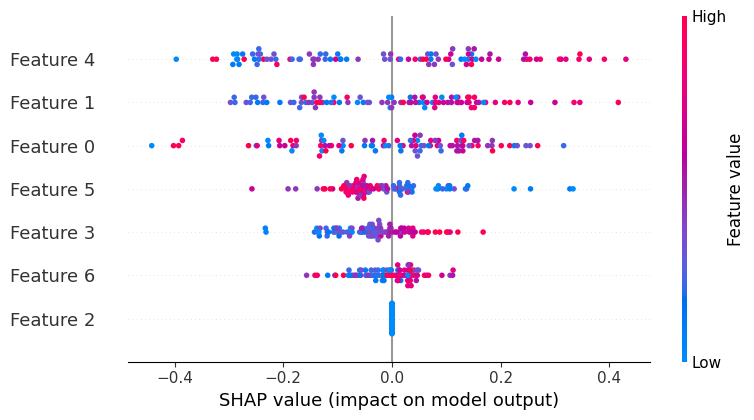

In [62]:
# Criar o modelo SVM
svm_model = SVC()
svm_model = SVC(probability=True)
# Treinar o modelo SVM
svm_model.fit(X_train, y_train)

# Fazer previsões com o modelo SVM
y_pred_svm = svm_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1 = f1_score(y_test, y_pred_svm, average = 'micro')


print(f'Acurácia do modelo SVM: {accuracy_svm * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')

explainer_svm_model = shap.KernelExplainer(svm_model.predict, X_train)
shap_values = explainer_svm_model.shap_values(X_test)

# Plotar o resumo dos valores SHAP
shap.summary_plot(shap_values, X_test)


Acurácia do modelo de Árvore de Decisão: 67.37%
F1 Score: 67.37%%


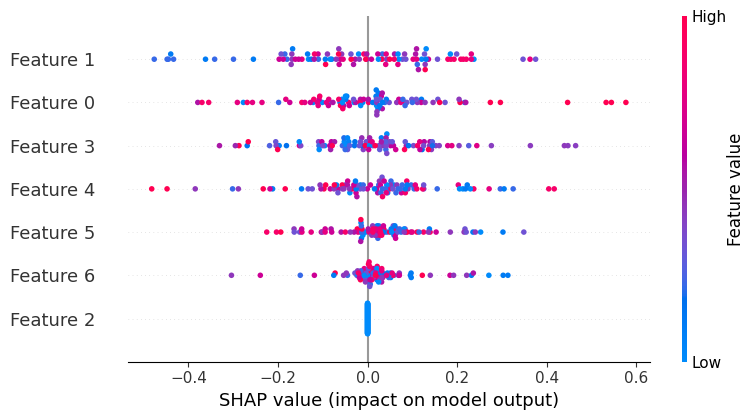

In [69]:
# Criar o modelo de Árvore de Decisão
tree_model = DecisionTreeClassifier()

# Treinar o modelo de Árvore de Decisão
tree_model.fit(X_train, y_train)

# Fazer previsões com o modelo de Árvore de Decisão
y_pred_tree = tree_model.predict(X_test)

# Calcular a acurácia e f1 score
accuracy_tree = accuracy_score(y_test, y_pred_tree)
f1 = f1_score(y_test, y_pred_tree, average = 'micro')

print(f'Acurácia do modelo de Árvore de Decisão: {accuracy_tree * 100:.2f}%')
print(f'F1 Score: {f1 * 100:.2f}%%')


explainer_tree_model = shap.TreeExplainer(tree_model)
shap_values = explainer_tree_model.shap_values(X_test)

shap.summary_plot(shap_values[:,:,1], X_test)

In [64]:
results = {"LCK4": {"Naive Bayes": accuracy, "Regressao Logistica": accuracy_logistic, "SVM": accuracy_svm, "Arvore de Decisao": accuracy_tree}}
with open("LCK4_results.json", "w") as f:
    json.dump(results, f)

In [65]:
# Executando a previsão pelo método de maior acurácia (Naive Bayes)
prevision = X_prediction
game_id = matches_df['game_id']
game_id_prev = game_id[train_size + test_size:]

result = matches_df['result_encoded']
result_prev = result[train_size + test_size:]

pred = model.predict(prevision)



df = pd.DataFrame({'Resultado': result_prev, 'Previsão': pred, 'Game_id': game_id_prev})
print(df)


     Resultado  Previsão  Game_id
481          0         0      481
482          0         1      482
494          0         1      494
483          1         0      483
495          0         0      495
..         ...       ...      ...
258          0         1      258
254          1         1      254
261          1         0      261
259          0         1      259
260          1         0      260

[96 rows x 3 columns]


<Axes: xlabel='Previsão', ylabel='Resultado'>

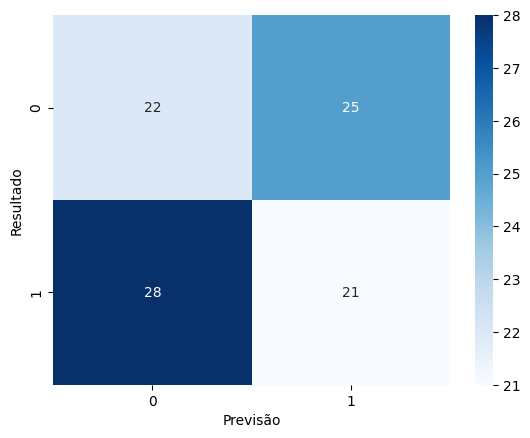

In [66]:
#Matrix de confusão
df = pd.DataFrame(df,columns = ['Resultado','Previsão'])

cf_matrix = pd.crosstab(df['Resultado'], df['Previsão'], rownames = ['Resultado'] , colnames = ['Previsão'])

sns.heatmap(cf_matrix, annot = True, cmap = 'Blues', fmt = 'g')